# Final Dataset Profiling - SMM08565 UECE
Scientific figures for international publication (IEEE Standard).

In [1]:
import sys
import os
import pandas as pd
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib
from matplotlib.patches import ConnectionPatch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import ListedColormap
from dataclasses import dataclass, field
from typing import Optional, Union, List, Dict, Any
from sklearn.base import BaseEstimator
from sklearn.utils.validation import check_is_fitted

# --- ROBUST ROOT DISCOVERY ---
def find_project_root(marker: str = "pyproject.toml") -> Path:
    """Locates the project root by searching upwards from the notebook location."""
    try:
        start_dir = Path(globals().get('_dh', [os.getcwd()])[0]).resolve()
    except (IndexError, NameError):
        start_dir = Path.cwd().resolve()

    current = start_dir
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            return parent
            
    # Fallback
    fallback = Path("/Users/fabiomachadomilan/Documents/GitHub/Rainfall-opensense_2026")
    return fallback if (fallback / marker).exists() else start_dir

# Detect & Set Root
project_root = find_project_root()
if Path.cwd() != project_root:
    os.chdir(project_root)
    if str(project_root) not in sys.path:
        sys.path.append(str(project_root))

print(f"✅ Project Root: {project_root}")

✅ Project Root: C:\Users\ggrmi\Documents\IC Tarcísio\Sound of Rainfall\Rainfall-opensense_2026


## 1. Configuration & Engine

In [2]:
@dataclass(frozen=True)
class VisualizationConfig:
    DEFAULT_OUTPUT_DIR: str = "reports/figures"
    IEEE_STYLE: Dict[str, Any] = field(default_factory=lambda: {
        'pdf.fonttype': 42,
        'font.family': 'serif',
        'font.serif': ['Times New Roman'],
        'font.size': 10,
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'legend.fontsize': 9,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'figure.dpi': 300,
        'savefig.bbox': 'tight',
        'axes.grid': False # Disabled global grid for cleaner matrices
    })

CONFIG = VisualizationConfig()

class VisualizationCore(BaseEstimator):
    def __init__(self, output_dir=CONFIG.DEFAULT_OUTPUT_DIR):
        self.output_dir = output_dir
        self.is_fitted_ = False

    def fit(self, X=None, y=None):
        self.validated_output_path_ = pathlib.Path(self.output_dir).resolve()
        self.validated_output_path_.mkdir(parents=True, exist_ok=True)
        self.style_context_ = CONFIG.IEEE_STYLE.copy()
        self.is_fitted_ = True
        return self

    def save(self, fig, filename):
        for fmt in ['pdf', 'png']:
            path = self.validated_output_path_ / f"{filename}.{fmt}"
            fig.savefig(path, format=fmt, dpi=300)

viz_core = VisualizationCore().fit()

## 2. Data Preparation & Harmonized Color Mapping

In [3]:
df = pd.read_csv(r"C:\Users\ggrmi\Documents\IC Tarcísio\Sound of Rainfall\Rainfall-opensense_2026\data\processed\IDSM_SMM00894-SMM08558_metadata_merged.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Padronização de Categorias
df['category'] = df['category'].replace({'no-rain': 'No Rain', 'no rain': 'No Rain'}).fillna('Unlabeled')
df['category'] = df['category'].replace({'Unknown': 'Unlabeled'}).str.title()

# Ordens Estritas
class_all = ['No Rain', 'Light', 'Moderate', 'Heavy', 'Violent', 'Unlabeled']
class_rain_only = ['Light', 'Moderate', 'Heavy', 'Violent']
months_order = pd.date_range(start='2024-12-01', end='2025-08-01', freq='MS').strftime('%b %Y').tolist()

df['category'] = pd.Categorical(df['category'], categories=class_all, ordered=True)
df['Month_Label'] = pd.Categorical(df['timestamp'].dt.strftime('%b %Y'), categories=months_order, ordered=True)

# Paletas de Cores
plasma_palette = sns.color_palette("plasma", n_colors=5)
color_map = {cls: col for cls, col in zip(class_all[:-1], plasma_palette)}
color_map['Unlabeled'] = '#999999'
palette_all = [color_map[c] for c in class_all]
palette_rain = [color_map[c] for c in class_rain_only]

total_dataset = len(df)

C:\Users\ggrmi\AppData\Local\Temp\ipykernel_7156\1099061132.py:14: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df['Month_Label'] = pd.Categorical(df['timestamp'].dt.strftime('%b %Y'), categories=months_order, ordered=True)


## 3. Visualizations

### 3.1. Scientific Donut Chart (Exploded Violent Class)

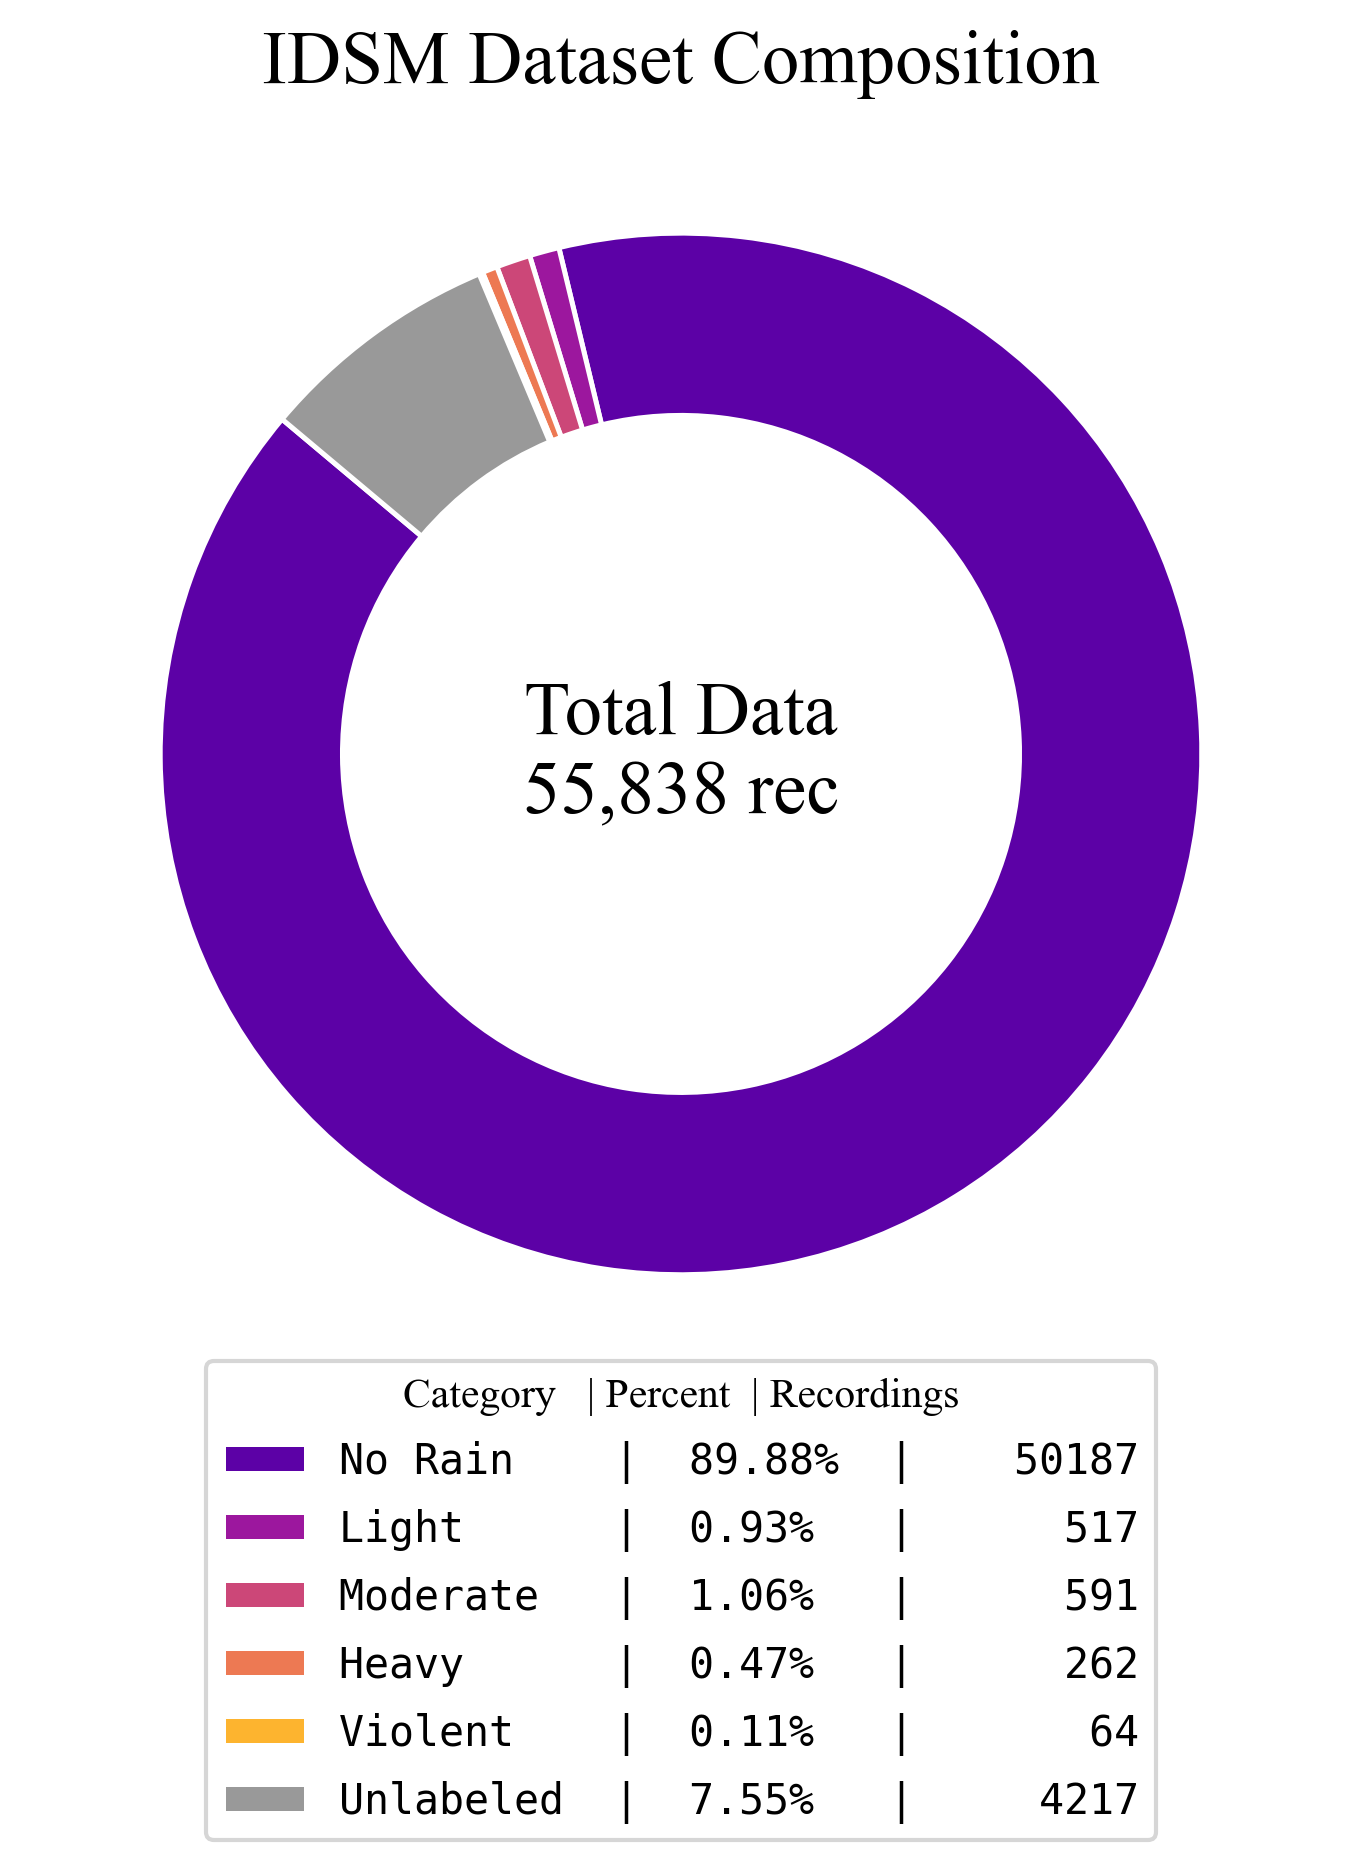

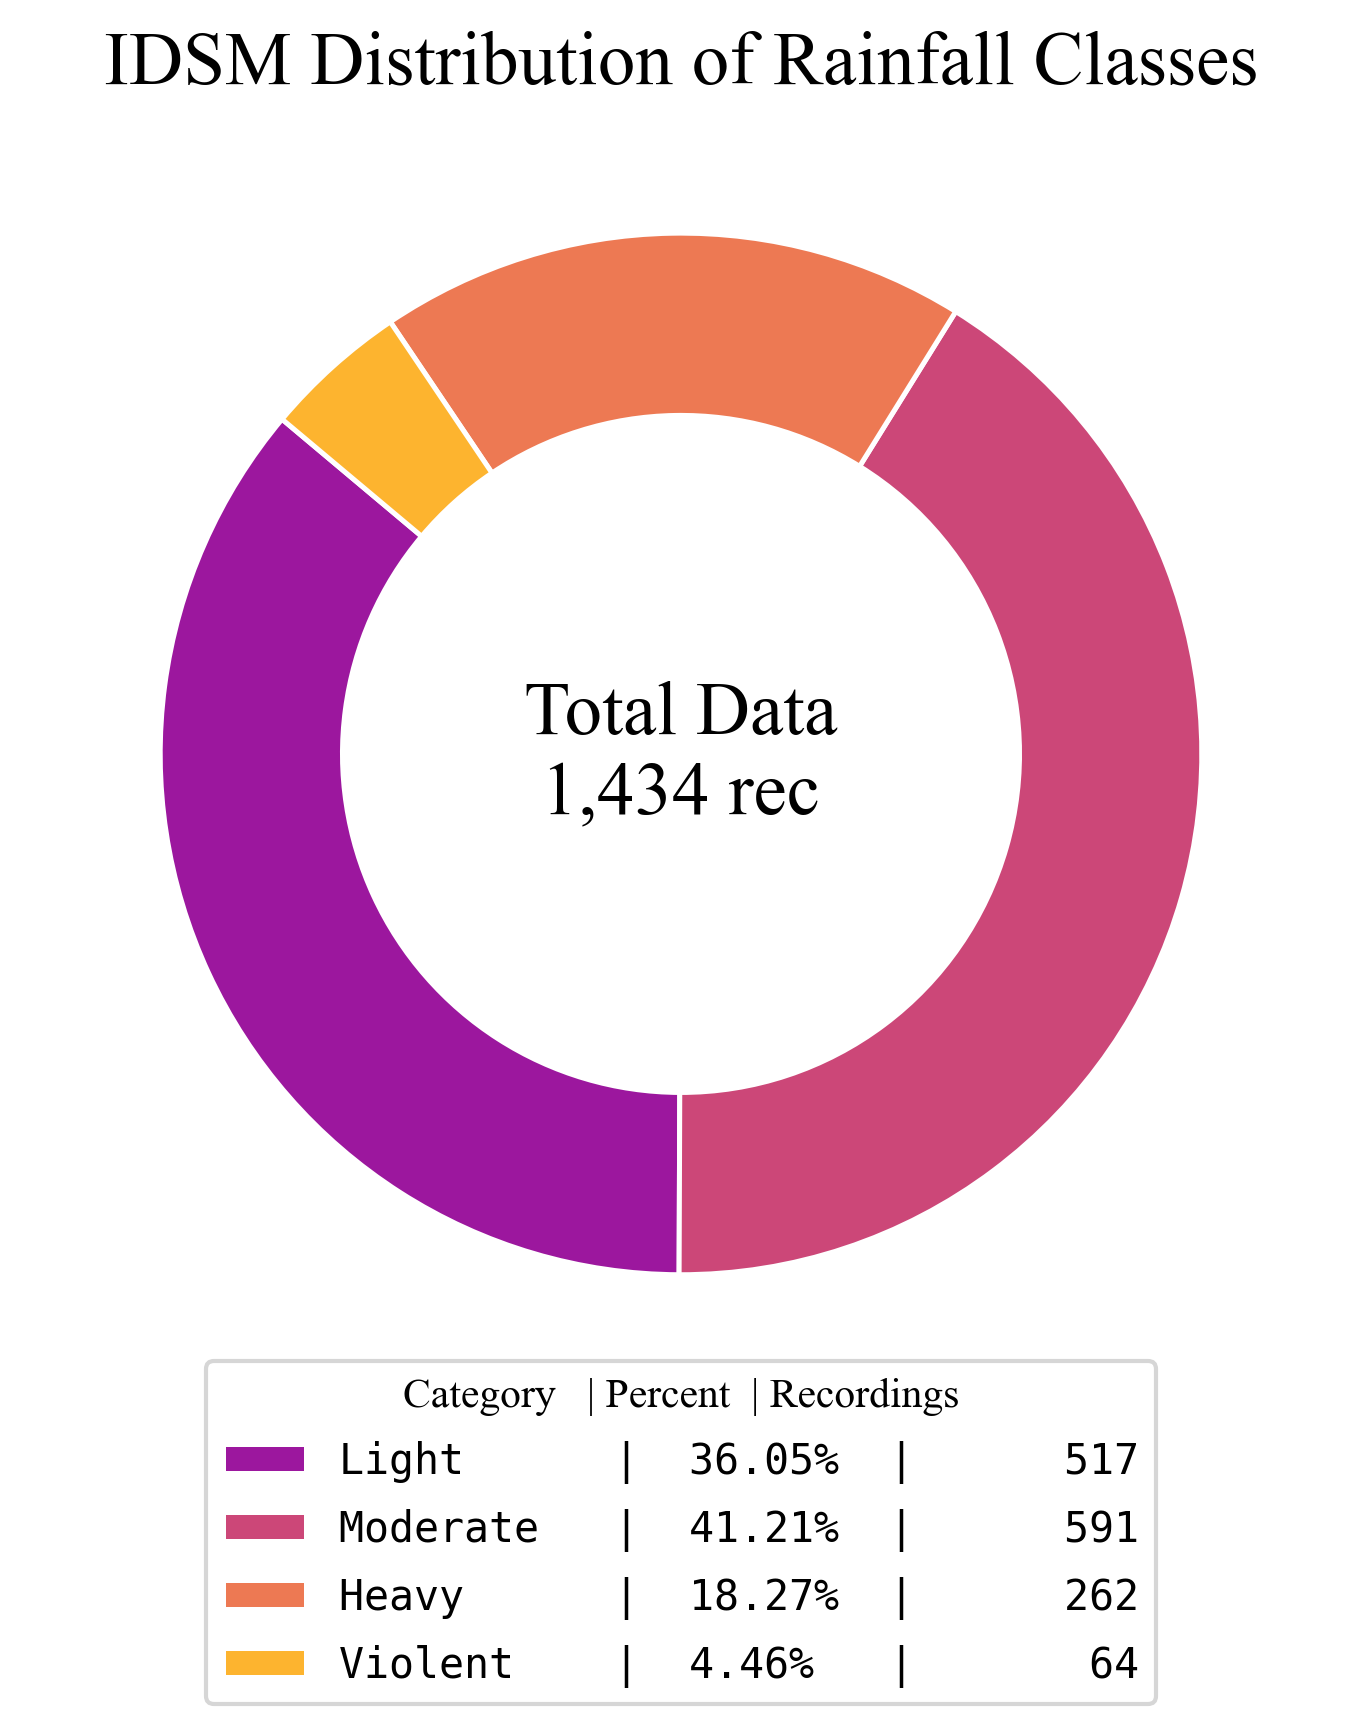

In [5]:
def plot_styled_donut(df, filename, categories, title):
    # 1. Preparação dos dados
    counts = df['category'].value_counts().reindex(categories).fillna(0)
    total_n = counts.sum()
    percentages = (counts / total_n) * 100
    colors = [color_map[c] for c in categories]
    
    
    # 3. Construção da Legenda estilo Tabela com alinhamento rigoroso
    # Definimos larguras fixas para cada coluna
    w_cat, w_per, w_rec = 10, 8, 8
    legend_labels = []
    
    for label, p, c in zip(categories, percentages, counts):
        row = f"{label.ljust(w_cat)} | {f'{p:.2f}%'.center(w_per)} | {str(c).rjust(w_rec)}"
        legend_labels.append(row)

    with plt.style.context(viz_core.style_context_):
        fig, ax = plt.subplots(figsize=(8, 7))
        
        # 2. O Donut
        wedges, _ = ax.pie(
            counts, 
            colors=colors, 
            startangle=140,
            wedgeprops={'width': 0.35, 'edgecolor': 'white', 'linewidth': 1.2},
            pctdistance=0.85
        )

        # 3. Texto Central
        ax.text(0, 0, f"Total Data\n{total_n:,} rec", 
                ha='center', va='center', 
                fontsize=18)

        # 4. Legenda Técnica Lateral
        # Posicionada para não interferir no gráfico
        ax.legend(
            wedges, 
            legend_labels,
            title=f"{'Category'.ljust(w_cat)} | {'Percent'.center(w_per)} | {'Recordings'.rjust(w_rec)}",
            loc="upper center",
            bbox_to_anchor=(0.5, 0.05), 
            frameon=True,
            prop={'family': 'monospace', 'size': 10}, # Fonte mono para alinhar colunas
            ncol=1,
            labelspacing=0.6
        )

        ax.set_title(title, fontsize=18, pad=5)
        plt.subplots_adjust(top=0.7, bottom=0.08)
    
        viz_core.save(fig, filename)
        plt.show()

plot_styled_donut(df, "IDSM_donut_all", class_all, "IDSM Dataset Composition")

df_rain_only = df[df['category'].isin(class_rain_only)].copy()
plot_styled_donut(df_rain_only, "IDSM_donut_rain", class_rain_only, "IDSM Distribution of Rainfall Classes")

### 3.2. Monthly Bars (Chronological Order)

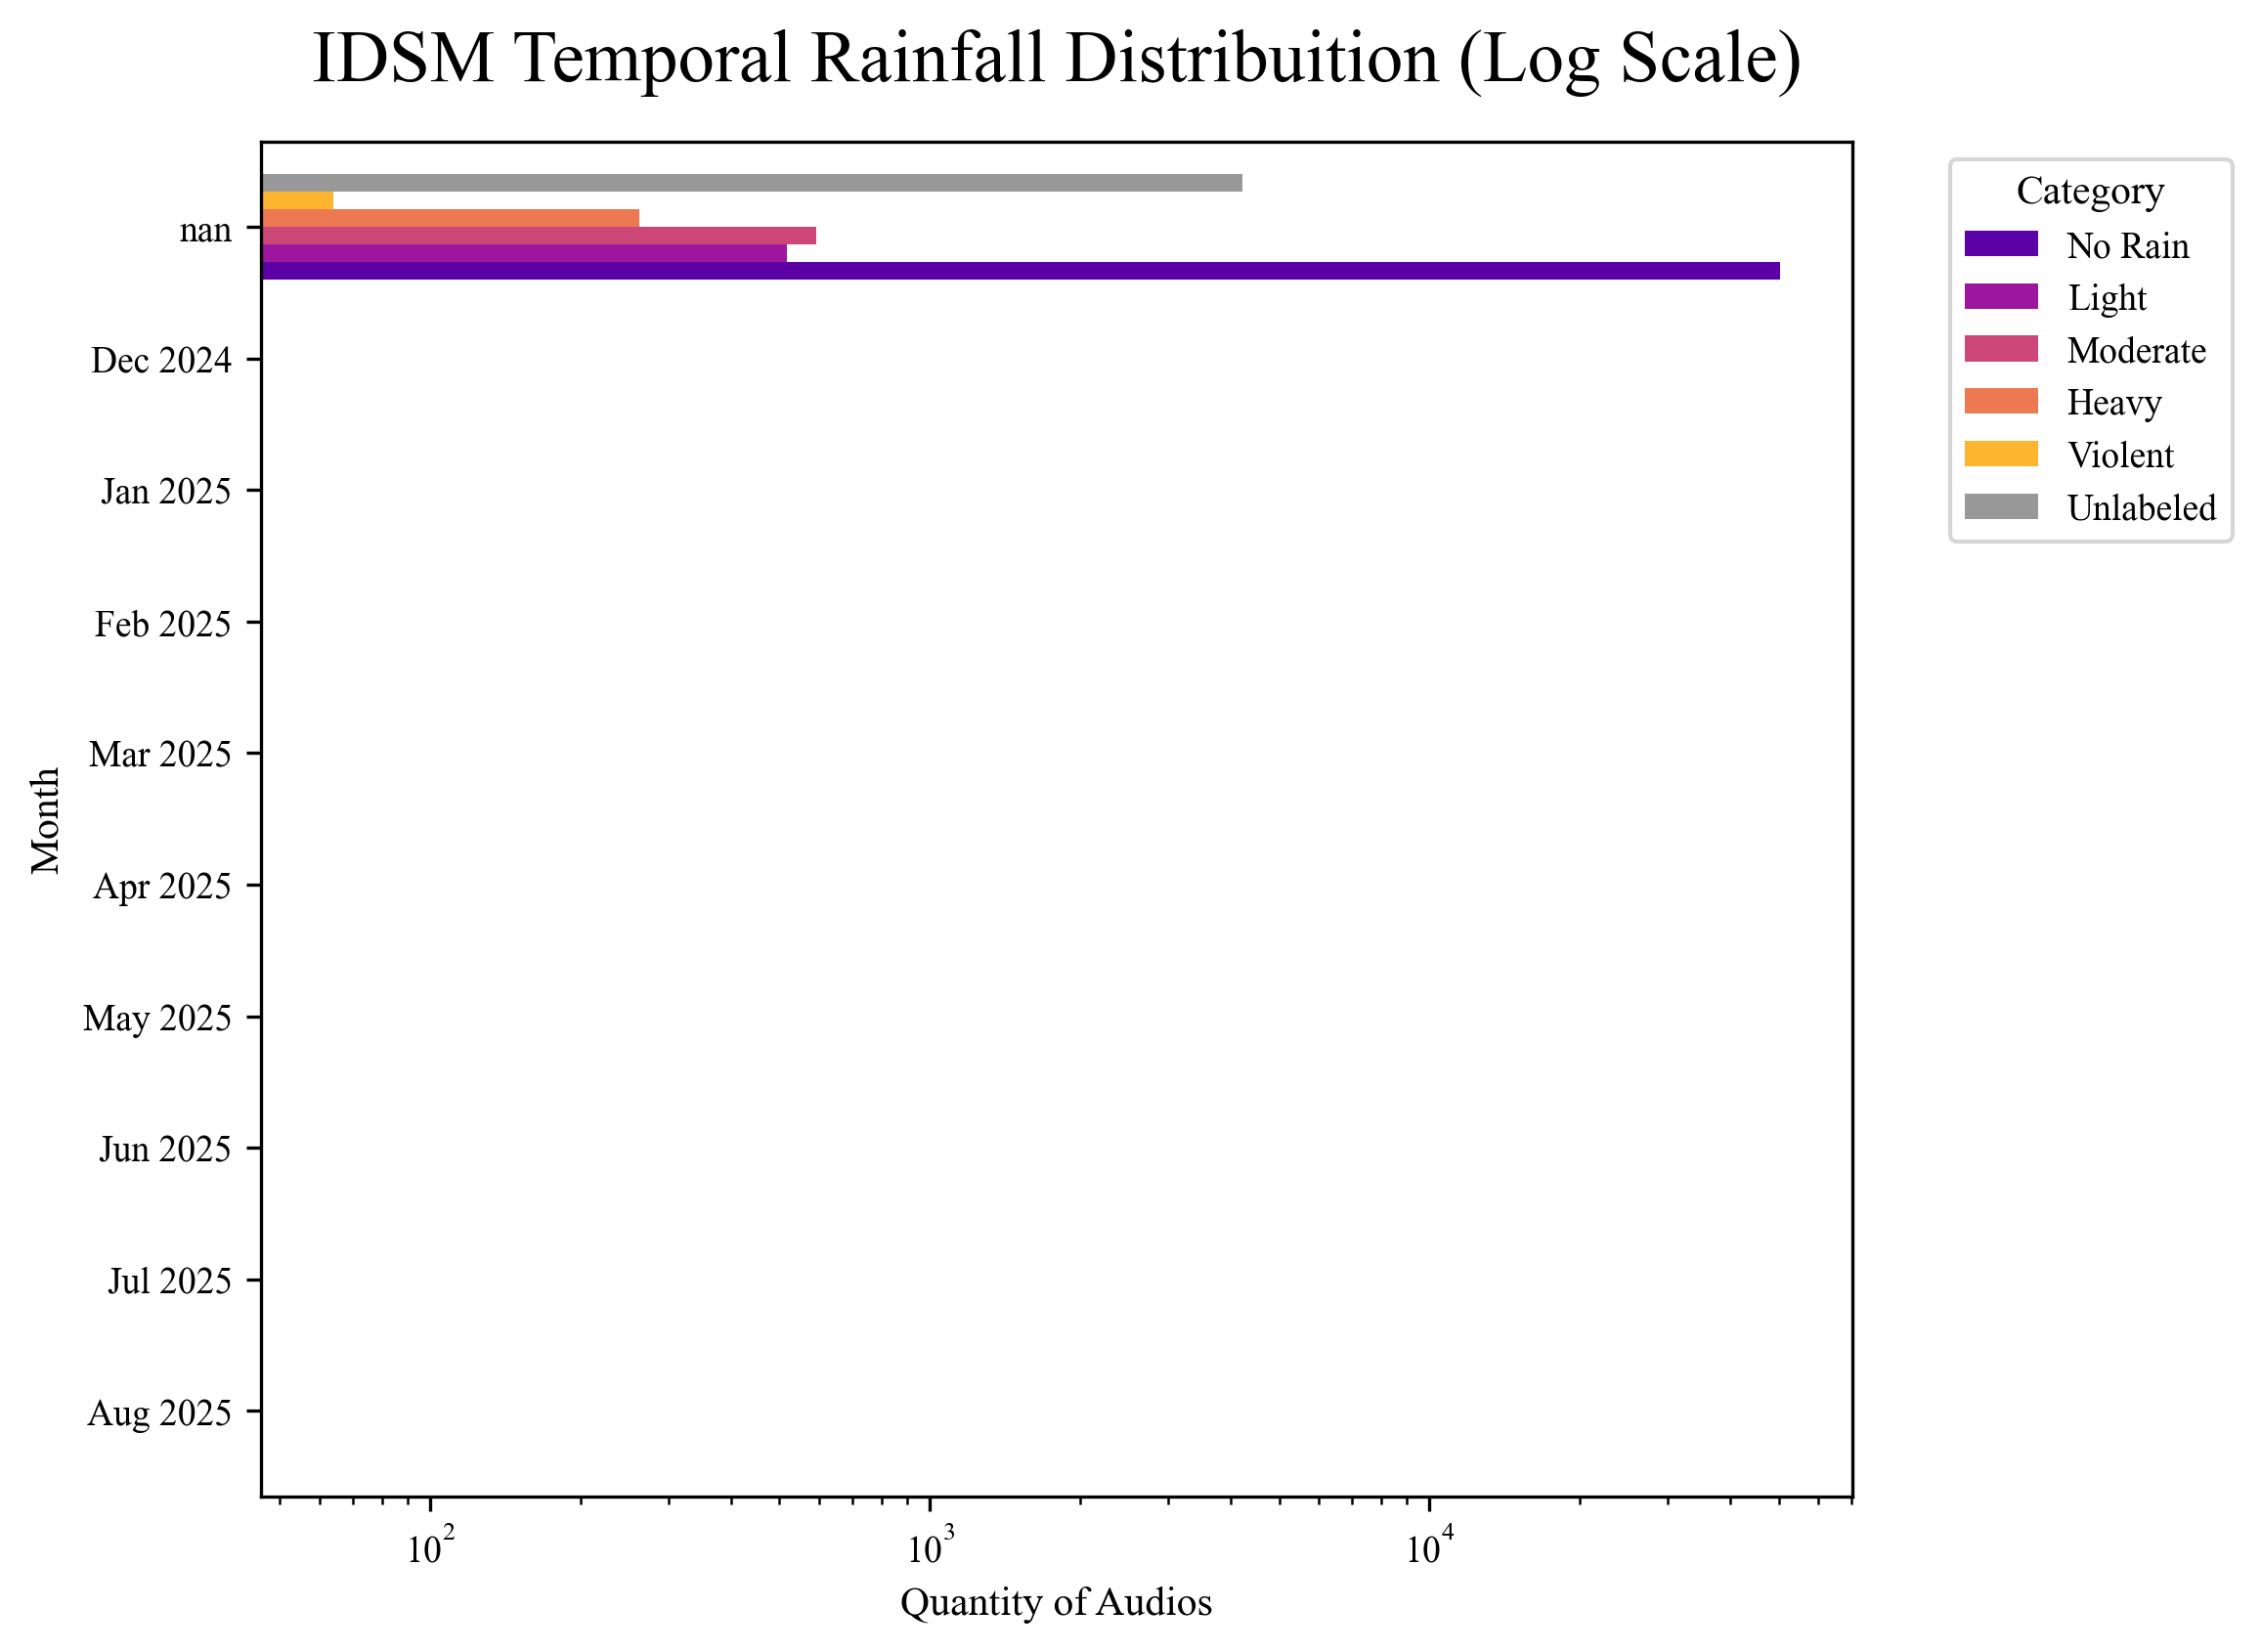

In [6]:
with plt.style.context(viz_core.style_context_):
    # Cross-tabulation
    monthly_data = pd.crosstab(df['Month_Label'], df['category'], dropna=False)
    
    fig, ax = plt.subplots(figsize=(7, 6))
    # Note: Month_Label order in index ensures Dec is top when plotting horizontally
    monthly_data.iloc[::-1].plot(kind='barh', ax=ax, width=0.8, color=palette_all)
    
    ax.set_xscale('log')
    ax.set_title("IDSM Temporal Rainfall Distribuition (Log Scale)", pad=15, fontsize=18)
    ax.set_xlabel("Quantity of Audios")
    ax.set_ylabel("Month")
    ax.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
    
    viz_core.save(fig, "IDSM_monthly_distribution_bars")
    plt.show()

### 3.3. Statistical Matrices (Quantity & Percentage)

In [ ]:
def plot_custom_matrix(data, title, filename, fmt="d"):
    """Matriz com zeros mascarados (fundo branco, texto cinza)."""
    with plt.style.context(viz_core.style_context_):
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Máscara para zeros
        mask = (data == 0)
        
        # Plot principal (dados > 0)
        sns.heatmap(data, annot=True, fmt=fmt, cmap="YlGnBu", mask=mask,
                    linewidths=1, linecolor='#F0F0F0', cbar=False, ax=ax)
        
        # Plot dos zeros (Fundo branco, texto cinza claro)
        sns.heatmap(data, annot=True, fmt=fmt, cmap=ListedColormap(['white']), 
                    mask=~mask, cbar=False, ax=ax, 
                    annot_kws={"color": "#D3D3D3"}, linewidths=1, linecolor='#F0F0F0')
        
        # Destaque das linhas de Total
        ax.axhline(data.shape[0]-1, color='black', linewidth=2)
        ax.axvline(data.shape[1]-1, color='black', linewidth=2)
        
        ax.set_title(title, pad=20)
        viz_core.save(fig, filename)
        plt.show()

## 4. Execução das Visualizações (Dataset Completo)

In [ ]:
# Matriz de Quantidades
matrix_q = pd.crosstab(df['Month_Label'], df['category'], dropna=False)
matrix_q['Row Total'] = matrix_q.sum(axis=1)
col_total = matrix_q.sum().to_frame().T
col_total.index = ['TOTAL']
matrix_q_final = pd.concat([matrix_q, col_total])

plot_custom_matrix(matrix_q_final, "Quantity Matrix (With Totals)", "matrix_quantities_all")

# Matriz de Porcentagens
# 1. Porcentagem da classe dentro do mês
matrix_p = pd.crosstab(df['Month_Label'], df['category'], normalize='index', dropna=False) * 100
# 2. Adiciona coluna de representatividade do mês no dataset total
month_weights = (df['Month_Label'].value_counts(normalize=True).reindex(months_order) * 100)
matrix_p['Month/Total %'] = month_weights

# Adiciona linha de total (média ponderada ou total geral por classe)
total_class_p = (df['category'].value_counts(normalize=True).reindex(class_all) * 100).to_frame().T
total_class_p.index = ['TOTAL %']
total_class_p['Month/Total %'] = 100.0
matrix_p_final = pd.concat([matrix_p, total_class_p])

plot_custom_matrix(matrix_p_final, "Monthly Percentage Matrix (Relative to Month Total)", "matrix_percentages_all", ".2f")


## 5. Execução das Visualizações (Apenas Chuva)

In [ ]:
df_rain = df[df['category'].isin(class_rain_only)].copy()
df_rain['category'] = df_rain['category'].cat.remove_unused_categories()

# Matriz de Porcentagens (Rain Only)
matrix_p_rain = pd.crosstab(df_rain['Month_Label'], df_rain['category'], normalize='index', dropna=False) * 100
month_weights_rain = (df_rain['Month_Label'].value_counts(normalize=True).reindex(months_order) * 100)
matrix_p_rain['Month/Total %'] = month_weights_rain

total_rain_p = (df_rain['category'].value_counts(normalize=True).reindex(class_rain_only) * 100).to_frame().T
total_rain_p.index = ['TOTAL %']
total_rain_p['Month/Total %'] = 100.0
matrix_p_rain_final = pd.concat([matrix_p_rain, total_rain_p])

plot_custom_matrix(matrix_p_rain_final, "Rain-Only Monthly Percentage Matrix", "matrix_percentages_rain", ".2f")